# CS506 Project Check-In (April): Boston Rent Prediction


- Finalized visualizations  
- Data processing summary 
- Modeling methods used so far  
- Results + interpretation  

Dataset used: `ma_boston_housing.csv` (Boston area listings filtered from the housing dataset) `housing.csv`(US housing dataset that I downloaded from kaggle)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Load

df = pd.read_csv("../data/ma_boston_housing.csv").copy()
df["description"] = df["description"].fillna("").astype(str)

# Convert numeric for coords
for col in ["price", "beds", "baths", "sqfeet", "lat", "long"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# match modeling price cleaning so plots are consistent
df = df[df["price"].notna()].copy()
df = df[(df["price"] >= 500) & (df["price"] <= 15000)]


# Engineered text features

luxury_keywords = [
    "luxury","renovated","stainless","granite","hardwood","doorman","concierge",
    "gym","fitness","roof deck","rooftop","central air","in-unit","in unit",
    "washer","dryer","laundry in unit","floor to ceiling","penthouse","garage",
    "valet","waterfront","pool","new construction"
]
transit_keywords = [
    "near t","mbta","red line","green line","orange line","blue line",
    "subway","station","commuter rail"
]

def keyword_score(text, keywords):
    t = str(text).lower()
    return sum(1 for kw in keywords if kw in t)

desc = df["description"].str.lower()
df["luxury_score"] = desc.apply(lambda t: keyword_score(t, luxury_keywords))
df["transit_score"] = desc.apply(lambda t: keyword_score(t, transit_keywords))
df["no_fee"] = desc.str.contains("no fee", na=False).astype(int)


# Mask bad coordinates

mask_good = df["lat"].between(42.0, 42.6) & df["long"].between(-71.4, -70.8)
df.loc[~mask_good, ["lat", "long"]] = np.nan  # keep listing, ignore bad location


# Location features

DOWNTOWN_LAT, DOWNTOWN_LON = 42.3601, -71.0589
df["dist_downtown"] = np.sqrt((df["lat"] - DOWNTOWN_LAT)**2 + (df["long"] - DOWNTOWN_LON)**2)

# geo_cluster (use the SAME k_geo as your final model; change 6 -> 12 if needed)
k_geo = 12
geo = df.dropna(subset=["lat", "long"])[["lat", "long"]].copy()
geo_scaled = StandardScaler().fit_transform(geo)
labels = KMeans(n_clusters=k_geo, random_state=42, n_init=10).fit_predict(geo_scaled)
df.loc[geo.index, "geo_cluster"] = labels
df["geo_cluster"] = df["geo_cluster"].fillna(-1).astype(int)

df.shape

(1576, 27)

## Data Processing Done So Far (Summary)

**Filtering**

Filtered the full USA housing listings dataset to state == "ma".
Further filtered to region == "boston" (Boston area listings).

**Type conversion (make columns usable)**

Converted key numeric columns to numeric types (coercing invalid strings to missing values):
price, beds, baths, sqfeet, lat, long
Filled missing listing text: description = "" when missing.

**Cleaning**

Removed listings with invalid or missing price.
Removed extreme price outliers (kept prices between $500 and $15,000) to reduce noise.
Deduplicated listings using the listing id.

**Location data quality (important update)**

Found that a small number of rows have clearly incorrect coordinates (lat/long far outside the Boston area).
Instead of dropping these listings entirely, I masked bad coordinates to missing values (NaN) so they do not corrupt location-based features or distance calculations.
Listings with missing/invalid coordinates are handled safely by imputation and a special cluster label (geo_cluster = -1).

**Feature engineering for modeling**

Quality / “high-end” signals from text:
luxury_score: counts luxury/amenity keywords (e.g., “luxury”, “renovated”, “doorman”, “roof deck”).
transit_score: counts transit-related keywords (e.g., “near T”, “MBTA”, line names).
no_fee: binary indicator for “no fee”.
Neighborhood / location proxy features:
dist_downtown: distance to downtown Boston (simple proxy for location premium).
geo_cluster: KMeans clustering on valid lat/long coordinates to create neighborhood-like groups (proxy neighborhood labels).
Listings without valid coordinates are assigned geo_cluster = -1.

## Preliminary Visualizations



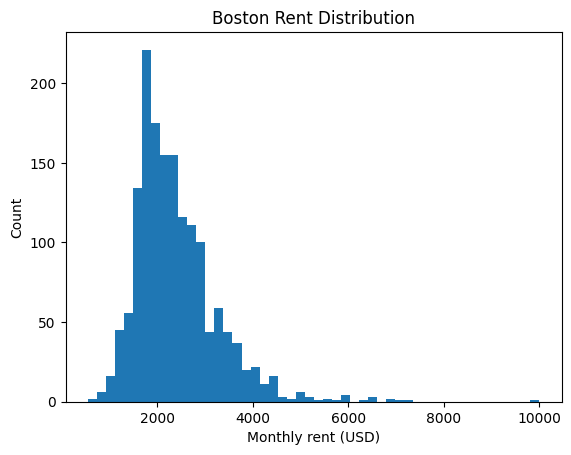

/var/folders/r8/ml4vhxjs71s5ynx4vpchtp_m0000gn/T/ipykernel_40556/1338739011.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


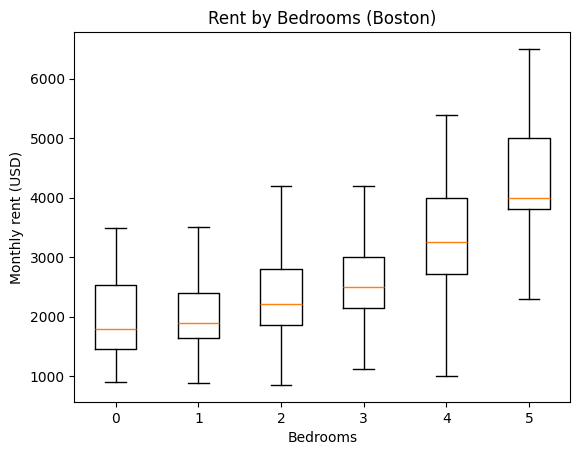

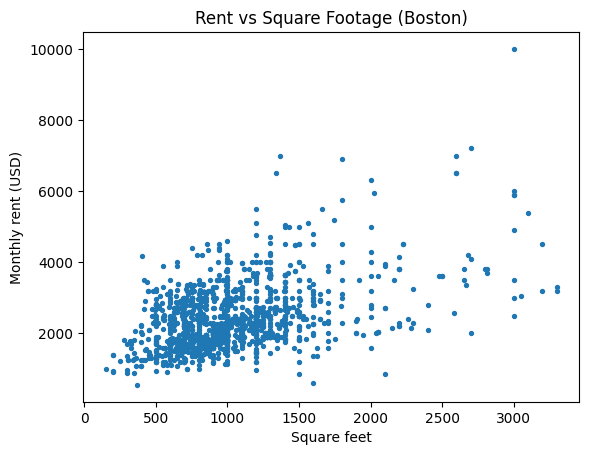

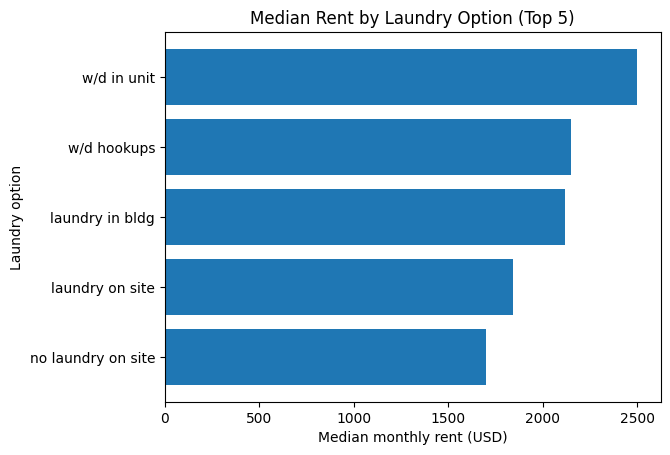

In [59]:
import matplotlib.pyplot as plt

# 1) Rent distribution
plt.figure()
plt.hist(df["price"], bins=50)
plt.title("Boston Rent Distribution")
plt.xlabel("Monthly rent (USD)")
plt.ylabel("Count")
plt.show()


# 2) Rent by bedrooms (boxplot)
if "beds" in df.columns:
    beds_vals = sorted([b for b in df["beds"].dropna().unique() if b <= 5])
    groups = [df.loc[df["beds"] == b, "price"].dropna() for b in beds_vals]
    labels = [str(b) for b in beds_vals]
    plt.figure()
    plt.boxplot(groups, labels=labels, showfliers=False)
    plt.title("Rent by Bedrooms (Boston)")
    plt.xlabel("Bedrooms")
    plt.ylabel("Monthly rent (USD)")
    plt.show()

# 3) Rent vs square footage (scatter)
if "sqfeet" in df.columns:
    sub = df.dropna(subset=["sqfeet"]).copy()
    # remove extreme sqft outliers for readability (optional)
    sub = sub[(sub["sqfeet"] > 100) & (sub["sqfeet"] < 5000)]
    plt.figure()
    plt.scatter(sub["sqfeet"], sub["price"], s=8)
    plt.title("Rent vs Square Footage (Boston)")
    plt.xlabel("Square feet")
    plt.ylabel("Monthly rent (USD)")
    plt.show()

# 4) Median rent by laundry option (example categorical insight)
if "laundry_options" in df.columns:
    med = df.groupby("laundry_options")["price"].median().sort_values(ascending=False)
    med = med[med.index.notna()]
    # show top 10 categories
    med = med.head(10)
    plt.figure()
    plt.barh(list(med.index)[::-1], list(med.values)[::-1])
    plt.title("Median Rent by Laundry Option (Top 5)")
    plt.xlabel("Median monthly rent (USD)")
    plt.ylabel("Laundry option")
    plt.show()



/var/folders/r8/ml4vhxjs71s5ynx4vpchtp_m0000gn/T/ipykernel_40556/1787274548.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["0","1","2","3+"], showfliers=False)


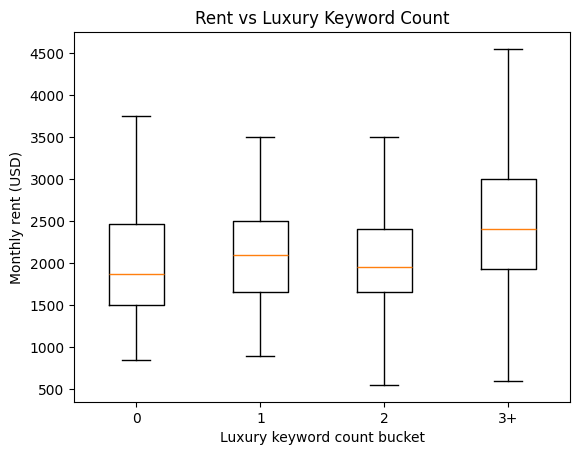

In [60]:
df["luxury_bucket"] = pd.cut(df["luxury_score"], bins=[-1,0,1,2,100], labels=["0","1","2","3+"])
groups = [df[df["luxury_bucket"]==b]["price"].dropna() for b in ["0","1","2","3+"]]

plt.figure()
plt.boxplot(groups, labels=["0","1","2","3+"], showfliers=False)
plt.title("Rent vs Luxury Keyword Count")
plt.xlabel("Luxury keyword count bucket")
plt.ylabel("Monthly rent (USD)")
plt.show()

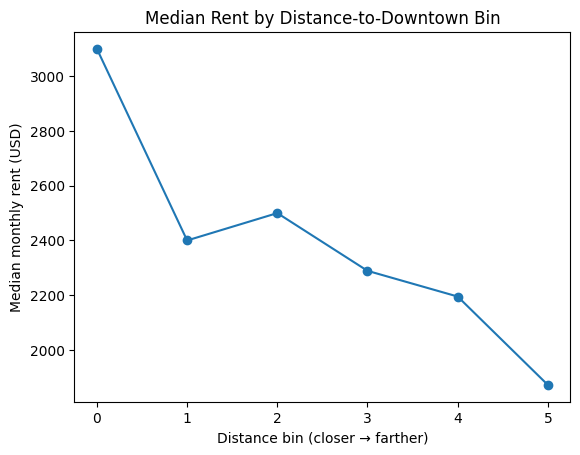

In [61]:
sub = df.dropna(subset=["dist_downtown","price"]).copy()
bins = pd.qcut(sub["dist_downtown"], q=6, duplicates="drop")
med = sub.groupby(bins)["price"].median()

plt.figure()
plt.plot(range(len(med)), med.values, marker="o")
plt.title("Median Rent by Distance-to-Downtown Bin")
plt.xlabel("Distance bin (closer → farther)")
plt.ylabel("Median monthly rent (USD)")
plt.show()

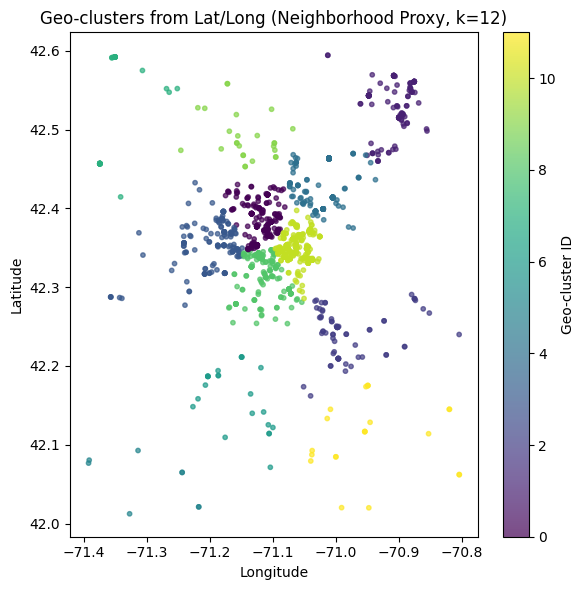

In [64]:
geo = df.dropna(subset=["lat","long","geo_cluster"]).copy()

plt.figure(figsize=(6,6))
sc = plt.scatter(
    geo["long"], geo["lat"],
    s=10, c=geo["geo_cluster"],
    alpha=0.7
)
plt.colorbar(sc, label="Geo-cluster ID")
plt.title("Geo-clusters from Lat/Long (Neighborhood Proxy, k=12)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

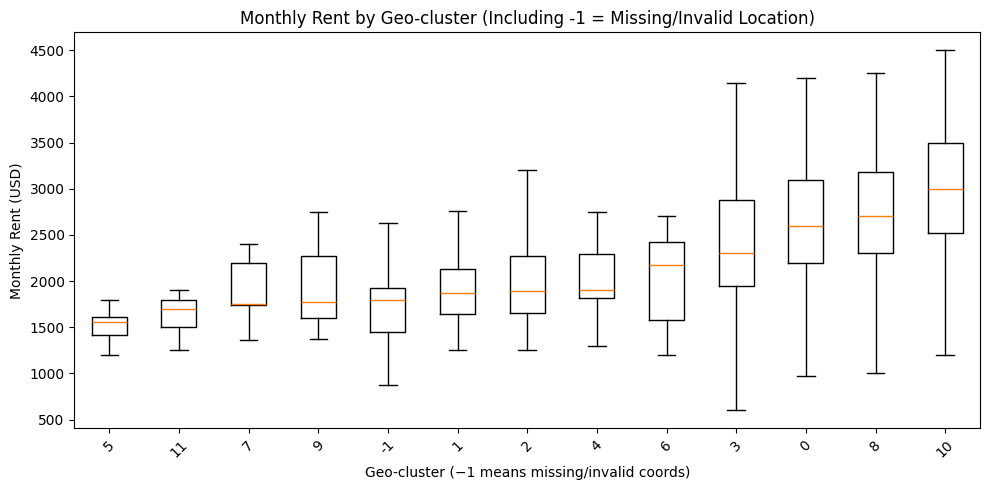

In [67]:
box_df = df.copy()  

# Sort clusters by median rent 
med = box_df.groupby("geo_cluster")["price"].median().sort_values()
sorted_clusters = med.index.tolist()

groups = [box_df.loc[box_df["geo_cluster"] == c, "price"].dropna() for c in sorted_clusters]

plt.figure(figsize=(10, 5))
plt.boxplot(
    groups,
    tick_labels=[str(c) for c in sorted_clusters],
    showfliers=False
)

plt.title("Monthly Rent by Geo-cluster (Including -1 = Missing/Invalid Location)")
plt.xlabel("Geo-cluster (−1 means missing/invalid coords)")
plt.ylabel("Monthly Rent (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Modeling Methods Used So Far

**Task:** Predict monthly rent price (`price`) from listing features.

**Baseline**
always predict the median rent from the training set.




# KNN

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cluster import KMeans


# Load + cleaning

df = pd.read_csv("../data/ma_boston_housing.csv").copy()
df["description"] = df["description"].fillna("").astype(str)

for col in ["price", "beds", "baths", "sqfeet", "lat", "long"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[df["price"].notna()].copy()
df = df[(df["price"] >= 500) & (df["price"] <= 15000)]
df = df.drop_duplicates(subset=["id"])


# Quality signals from text

luxury_keywords = [
    "luxury","renovated","stainless","granite","hardwood","doorman","concierge",
    "gym","fitness","roof deck","rooftop","central air","in-unit","in unit",
    "washer","dryer","laundry in unit","floor to ceiling","penthouse","garage",
    "valet","waterfront","pool","new construction"
]
transit_keywords = [
    "near t","mbta","red line","green line","orange line","blue line",
    "subway","station","commuter rail"
]

def keyword_score(text, keywords):
    t = str(text).lower()
    return sum(1 for kw in keywords if kw in t)

desc = df["description"].str.lower()
df["luxury_score"] = desc.apply(lambda t: keyword_score(t, luxury_keywords))
df["transit_score"] = desc.apply(lambda t: keyword_score(t, transit_keywords))
df["no_fee"] = desc.str.contains("no fee", na=False).astype(int)

# Handle bad coordinates (keep listing, ignore location)

mask_good = df["lat"].between(42.0, 42.6) & df["long"].between(-71.4, -70.8)

# Set bad coords to missing so they don't corrupt distances / clustering
df.loc[~mask_good, ["lat", "long"]] = np.nan

# Location / neighborhood proxy features

DOWNTOWN_LAT, DOWNTOWN_LON = 42.3601, -71.0589

if "lat" in df.columns and "long" in df.columns:
    df["dist_downtown"] = np.sqrt((df["lat"] - DOWNTOWN_LAT)**2 + (df["long"] - DOWNTOWN_LON)**2)

    geo = df[["lat", "long"]].dropna().copy()
    if len(geo) > 50:
        geo_scaled = StandardScaler().fit_transform(geo)
        k_geo = 12
        geo_labels = KMeans(n_clusters=k_geo, random_state=42, n_init=10).fit_predict(geo_scaled)
        df.loc[geo.index, "geo_cluster"] = geo_labels
    df["geo_cluster"] = df.get("geo_cluster", -1).fillna(-1).astype(int)


# Features

text_feature = "description"

num_features = [c for c in [
    "beds","baths","sqfeet","lat","long",
    "luxury_score","transit_score","no_fee",
    "dist_downtown"
] if c in df.columns]

cat_features = [c for c in ["type","laundry_options","parking_options","geo_cluster"] if c in df.columns]

X = df[num_features + cat_features + [text_feature]].copy()
y = df["price"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

baseline_pred = np.full(shape=len(y_test), fill_value=y_train.median())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print("Baseline (median) MAE:", round(baseline_mae, 2))


# Tuned LSA + KNN 

text_pipe = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=30000,
        min_df=3,
        ngram_range=(1, 2)
    )),
    ("svd", TruncatedSVD(n_components=75, random_state=42)),
    ("scale", StandardScaler())
])

num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("text", text_pipe, text_feature),
        ("num", num_pipe, num_features),
        ("cat", cat_pipe, cat_features),
    ],
    remainder="drop"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("knn", KNeighborsRegressor(n_neighbors=5, weights="distance"))
])

model.fit(X_train, y_train)
pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)

print("Location-improved tuned LSA + KNN MAE:", round(mae, 2))
print("Improvement (baseline - model):", round(baseline_mae - mae, 2))

Baseline (median) MAE: 602.59
Location-improved tuned LSA + KNN MAE: 299.45
Improvement (baseline - model): 303.14


# Tuning K and SVD Components

In [52]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

k_list = [3, 5, 7, 10, 15]
comp_list = [25, 50, 75]

results = []

for n_comp in comp_list:
    # rebuild text pipeline each time with different SVD dimension
    text_pipe_tmp = Pipeline(steps=[
        ("tfidf", TfidfVectorizer(
            stop_words="english",
            max_features=30000,
            min_df=3,
            ngram_range=(1, 2)
        )),
        ("svd", TruncatedSVD(n_components=n_comp, random_state=42)),
        ("scale", StandardScaler())
    ])

    num_pipe_tmp = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    cat_pipe_tmp = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocess_tmp = ColumnTransformer(
        transformers=[
            ("text", text_pipe_tmp, text_feature),
            ("num", num_pipe_tmp, num_features),
            ("cat", cat_pipe_tmp, cat_features),
        ],
        remainder="drop"
    )

    for k in k_list:
        model_tmp = Pipeline(steps=[
            ("preprocess", preprocess_tmp),
            ("knn", KNeighborsRegressor(n_neighbors=k, weights="distance"))
        ])

        model_tmp.fit(X_train, y_train)
        pred = model_tmp.predict(X_test)
        mae = mean_absolute_error(y_test, pred)

        results.append((n_comp, k, mae))
        print(f"n_comp={n_comp:<3}  k={k:<2}  MAE={mae:.2f}")

best_n, best_k, best_mae = min(results, key=lambda t: t[2])
print("\nBEST SETTINGS:")
print("n_components =", best_n)
print("k =", best_k)
print("MAE =", round(best_mae, 2))

n_comp=25   k=3   MAE=286.26
n_comp=25   k=5   MAE=267.56
n_comp=25   k=7   MAE=263.67
n_comp=25   k=10  MAE=274.44
n_comp=25   k=15  MAE=274.24
n_comp=50   k=3   MAE=301.11
n_comp=50   k=5   MAE=291.74
n_comp=50   k=7   MAE=289.59
n_comp=50   k=10  MAE=295.47
n_comp=50   k=15  MAE=298.81
n_comp=75   k=3   MAE=316.02
n_comp=75   k=5   MAE=299.45
n_comp=75   k=7   MAE=296.31
n_comp=75   k=10  MAE=299.02
n_comp=75   k=15  MAE=313.31

BEST SETTINGS:
n_components = 25
k = 7
MAE = 263.67


# Tuning K-geo and whether I should include lat/long as numeric features

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error


# fixed settings (from your best model)
N_COMP = 25
KNN_K = 7

k_geo_list = [6, 8, 10, 12, 16, 20]
results = []

# Prepare shared text/numeric/cat pipelines (we will rebuild ColumnTransformer because columns differ)
text_pipe = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=30000,
        min_df=3,
        ngram_range=(1, 2)
    )),
    ("svd", TruncatedSVD(n_components=N_COMP, random_state=42)),
    ("scale", StandardScaler())
])

num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

text_feature = "description"
base_num = [c for c in ["beds","baths","sqfeet","luxury_score","transit_score","no_fee","dist_downtown"] if c in df.columns]
base_cat = [c for c in ["type","laundry_options","parking_options"] if c in df.columns]

from sklearn.model_selection import train_test_split

for k_geo in k_geo_list:
    df_tmp = df.copy()

    # geo_cluster creation
    geo = df_tmp[["lat","long"]].dropna().copy()
    geo_scaled = StandardScaler().fit_transform(geo)
    df_tmp.loc[geo.index, "geo_cluster"] = KMeans(n_clusters=k_geo, random_state=42, n_init=10).fit_predict(geo_scaled)
    df_tmp["geo_cluster"] = df_tmp["geo_cluster"].fillna(-1).astype(int)

    # Two configurations
    for use_latlong in [True, False]:
        num_features = base_num.copy()
        if use_latlong:
            num_features += [c for c in ["lat","long"] if c in df_tmp.columns]

        cat_features = base_cat + ["geo_cluster"]

        X = df_tmp[num_features + cat_features + [text_feature]].copy()
        y = df_tmp["price"].copy()

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        preprocess = ColumnTransformer(
            transformers=[
                ("text", text_pipe, text_feature),
                ("num", num_pipe, num_features),
                ("cat", cat_pipe, cat_features),
            ],
            remainder="drop"
        )

        model = Pipeline(steps=[
            ("preprocess", preprocess),
            ("knn", KNeighborsRegressor(n_neighbors=KNN_K, weights="distance"))
        ])

        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, pred)

        results.append((k_geo, use_latlong, mae))
        mode = "lat/long+cluster" if use_latlong else "cluster-only"
        print(f"k_geo={k_geo:<2}  mode={mode:<14}  MAE={mae:.2f}")

best = min(results, key=lambda t: t[2])
print("\nBEST:", best)

k_geo=6   mode=lat/long+cluster  MAE=271.15
k_geo=6   mode=cluster-only    MAE=274.52
k_geo=8   mode=lat/long+cluster  MAE=266.97
k_geo=8   mode=cluster-only    MAE=276.54
k_geo=10  mode=lat/long+cluster  MAE=267.18
k_geo=10  mode=cluster-only    MAE=266.95
k_geo=12  mode=lat/long+cluster  MAE=263.67
k_geo=12  mode=cluster-only    MAE=270.08
k_geo=16  mode=lat/long+cluster  MAE=269.64
k_geo=16  mode=cluster-only    MAE=273.16
k_geo=20  mode=lat/long+cluster  MAE=268.27
k_geo=20  mode=cluster-only    MAE=265.33

BEST: (12, True, 263.66665800886835)


# Trying Linear SVR using the same features

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

from sklearn.svm import LinearSVR


# Load + cleaning

df = pd.read_csv("../data/ma_boston_housing.csv").copy()
df["description"] = df["description"].fillna("").astype(str)

for col in ["price", "beds", "baths", "sqfeet", "lat", "long"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[df["price"].notna()].copy()
df = df[(df["price"] >= 500) & (df["price"] <= 15000)]
df = df.drop_duplicates(subset=["id"])


# Engineered quality signals

luxury_keywords = [
    "luxury","renovated","stainless","granite","hardwood","doorman","concierge",
    "gym","fitness","roof deck","rooftop","central air","in-unit","in unit",
    "washer","dryer","laundry in unit","floor to ceiling","penthouse","garage",
    "valet","waterfront","pool","new construction"
]
transit_keywords = [
    "near t","mbta","red line","green line","orange line","blue line",
    "subway","station","commuter rail"
]

def keyword_score(text, keywords):
    t = str(text).lower()
    return sum(1 for kw in keywords if kw in t)

desc = df["description"].str.lower()
df["luxury_score"] = desc.apply(lambda t: keyword_score(t, luxury_keywords))
df["transit_score"] = desc.apply(lambda t: keyword_score(t, transit_keywords))
df["no_fee"] = desc.str.contains("no fee", na=False).astype(int)

# Handle bad coordinates (keep listing, ignore location)

mask_good = df["lat"].between(42.0, 42.6) & df["long"].between(-71.4, -70.8)

# Set bad coords to missing so they don't corrupt distances / clustering
df.loc[~mask_good, ["lat", "long"]] = np.nan

# Location / neighborhood proxy (same as your best setup)

DOWNTOWN_LAT, DOWNTOWN_LON = 42.3601, -71.0589
df["dist_downtown"] = np.sqrt((df["lat"] - DOWNTOWN_LAT)**2 + (df["long"] - DOWNTOWN_LON)**2)

geo = df[["lat", "long"]].dropna().copy()
geo_scaled = StandardScaler().fit_transform(geo)
df.loc[geo.index, "geo_cluster"] = KMeans(n_clusters=6, random_state=42, n_init=10).fit_predict(geo_scaled)
df["geo_cluster"] = df["geo_cluster"].fillna(-1).astype(int)


# Features

text_feature = "description"

num_features = [c for c in [
    "beds","baths","sqfeet","lat","long","dist_downtown",
    "luxury_score","transit_score","no_fee"
] if c in df.columns]

cat_features = [c for c in ["type","laundry_options","parking_options","geo_cluster"] if c in df.columns]

X = df[num_features + cat_features + [text_feature]].copy()
y = df["price"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Baseline

baseline_pred = np.full(shape=len(y_test), fill_value=y_train.median())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print("Baseline (median) MAE:", round(baseline_mae, 2))


# Preprocess: Text (LSA) + Numeric + Categorical

text_pipe = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=30000,
        min_df=3,
        ngram_range=(1, 2)
    )),
    ("svd", TruncatedSVD(n_components=75, random_state=42)),
    ("scale", StandardScaler())
])

num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("text", text_pipe, text_feature),
        ("num", num_pipe, num_features),
        ("cat", cat_pipe, cat_features),
    ],
    remainder="drop"
)


# Linear SVR model

svr = LinearSVR(
    C=1.0,          # default c and episilon
    epsilon=0.0,    
    random_state=42,
    max_iter=20000
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("svr", svr)
])

model.fit(X_train, y_train)
pred = model.predict(X_test)
svr_mae = mean_absolute_error(y_test, pred)

print("LinearSVR MAE:", round(svr_mae, 2))
print("Improvement (baseline - SVR):", round(baseline_mae - svr_mae, 2))

Baseline (median) MAE: 602.59
LinearSVR MAE: 516.97
Improvement (baseline - SVR): 85.62


# Tuning C and Episilon for Linear SVR

In [56]:
from sklearn.svm import LinearSVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

for C in [0.1, 0.5, 1.0, 2.0, 5.0]:
    for eps in [0.0, 50.0, 100.0, 200.0]:
        svr = LinearSVR(C=C, epsilon=eps, random_state=42, max_iter=50000)
        model = Pipeline([("preprocess", preprocess), ("svr", svr)])
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, pred)
        print(f"C={C:<3}  eps={eps:<5}  MAE={mae:.2f}")

C=0.1  eps=0.0    MAE=2030.07
C=0.1  eps=50.0   MAE=2030.07
C=0.1  eps=100.0  MAE=2030.07
C=0.1  eps=200.0  MAE=2030.07
C=0.5  eps=0.0    MAE=866.55
C=0.5  eps=50.0   MAE=872.27
C=0.5  eps=100.0  MAE=882.05
C=0.5  eps=200.0  MAE=909.95
C=1.0  eps=0.0    MAE=516.97
C=1.0  eps=50.0   MAE=523.80
C=1.0  eps=100.0  MAE=530.94
C=1.0  eps=200.0  MAE=555.12
C=2.0  eps=0.0    MAE=406.37
C=2.0  eps=50.0   MAE=406.02
C=2.0  eps=100.0  MAE=404.76
C=2.0  eps=200.0  MAE=415.58
C=5.0  eps=0.0    MAE=324.80
C=5.0  eps=50.0   MAE=330.93
C=5.0  eps=100.0  MAE=340.85
C=5.0  eps=200.0  MAE=350.69


# Best Model-KNN

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cluster import KMeans


# Load + cleaning

df = pd.read_csv("../data/ma_boston_housing.csv").copy()
df["description"] = df["description"].fillna("").astype(str)

for col in ["price", "beds", "baths", "sqfeet", "lat", "long"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[df["price"].notna()].copy()
df = df[(df["price"] >= 500) & (df["price"] <= 15000)]
df = df.drop_duplicates(subset=["id"])

# Engineered quality signals

luxury_keywords = [
    "luxury","renovated","stainless","granite","hardwood","doorman","concierge",
    "gym","fitness","roof deck","rooftop","central air","in-unit","in unit",
    "washer","dryer","laundry in unit","floor to ceiling","penthouse","garage",
    "valet","waterfront","pool","new construction"
]
transit_keywords = [
    "near t","mbta","red line","green line","orange line","blue line",
    "subway","station","commuter rail"
]

def keyword_score(text, keywords):
    t = str(text).lower()
    return sum(1 for kw in keywords if kw in t)

desc = df["description"].str.lower()
df["luxury_score"] = desc.apply(lambda t: keyword_score(t, luxury_keywords))
df["transit_score"] = desc.apply(lambda t: keyword_score(t, transit_keywords))
df["no_fee"] = desc.str.contains("no fee", na=False).astype(int)


# Mask bad coordinates

mask_good = df["lat"].between(42.0, 42.6) & df["long"].between(-71.4, -70.8)
df.loc[~mask_good, ["lat", "long"]] = np.nan   # keep row, ignore location


# Location / neighborhood proxy features (BEST retuned setting)

DOWNTOWN_LAT, DOWNTOWN_LON = 42.3601, -71.0589
df["dist_downtown"] = np.sqrt((df["lat"] - DOWNTOWN_LAT)**2 + (df["long"] - DOWNTOWN_LON)**2)

# geo_cluster with k_geo = 12, built only on valid coords
geo = df.dropna(subset=["lat", "long"])[["lat", "long"]].copy()
geo_scaled = StandardScaler().fit_transform(geo)
df.loc[geo.index, "geo_cluster"] = KMeans(n_clusters=12, random_state=42, n_init=10).fit_predict(geo_scaled)
df["geo_cluster"] = df["geo_cluster"].fillna(-1).astype(int)


# Features

text_feature = "description"
num_features = [c for c in [
    "beds","baths","sqfeet","lat","long","dist_downtown",
    "luxury_score","transit_score","no_fee"
] if c in df.columns]

cat_features = [c for c in ["type","laundry_options","parking_options","geo_cluster"] if c in df.columns]

X = df[num_features + cat_features + [text_feature]].copy()
y = df["price"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Baseline

baseline_pred = np.full(shape=len(y_test), fill_value=y_train.median())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print("Baseline (median) MAE:", round(baseline_mae, 2))


# BEST retuned LSA + KNN settings

text_pipe = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=30000,
        min_df=3,
        ngram_range=(1, 2)
    )),
    ("svd", TruncatedSVD(n_components=25, random_state=42)),
    ("scale", StandardScaler())
])

num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("text", text_pipe, text_feature),
        ("num", num_pipe, num_features),
        ("cat", cat_pipe, cat_features),
    ],
    remainder="drop"
)

best_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("knn", KNeighborsRegressor(n_neighbors=7, weights="distance"))
])

best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

best_mae = mean_absolute_error(y_test, pred)
print("BEST retuned model MAE (mask coords + k_geo=12 + SVD=25 + KNN k=7):", round(best_mae, 2))
print("Improvement (baseline - best):", round(baseline_mae - best_mae, 2))

Baseline (median) MAE: 602.59
BEST retuned model MAE (mask coords + k_geo=12 + SVD=25 + KNN k=7): 263.67
Improvement (baseline - best): 338.92
